In [1]:
# ==============================
# Step 1: Import Libraries
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping


In [3]:
# ==============================
# Step 2: Load Dataset
# ==============================
df = pd.read_csv("1_boston_housing.csv")

# Remove unwanted quotes from column names
df.columns = df.columns.str.replace('"', '')

# Display dataset
print(df.head())


      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [5]:
# ==============================
# Step 3: Split Features & Target
# ==============================
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (506, 13)
Shape of y: (506,)


In [7]:
# ==============================
# Step 4: Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# ==============================
# Step 5: Feature Scaling
# ==============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# ==============================
# Step 6: Build Deep Neural Network
# ==============================
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    
    Dense(1, activation='linear')   # Output layer (Regression)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# ==============================
# Step 7: Train Model
# ==============================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 596.2578 - mae: 22.5222 - val_loss: 507.1990 - val_mae: 20.9720
Epoch 2/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 509.6068 - mae: 20.5208 - val_loss: 388.5161 - val_mae: 18.0111
Epoch 3/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 337.4387 - mae: 16.0818 - val_loss: 190.8843 - val_mae: 12.0357
Epoch 4/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 133.2421 - mae: 9.3478 - val_loss: 52.4984 - val_mae: 5.2802
Epoch 5/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 56.9768 - mae: 6.0596 - val_loss: 31.2399 - val_mae: 4.1673
Epoch 6/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 35.2876 - mae: 4.6368 - val_loss: 24.8290 - val_mae: 3.6694
Epoch 7/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 26.1467 - mae: 3.8288 - val_loss: 24.5066 - val_mae: 3.5973
Epoch 8/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 21.7315 - mae: 3.4983 - val_loss: 22.7199 - val_mae: 3.4235
Epoch 9/200
21/21 ━━━━━━━━━

In [15]:
# ==============================
# Step 8: Evaluate Model
# ==============================
loss, mae = model.evaluate(X_test, y_test)

print("\nTest Loss (MSE):", loss)
print("Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 11.8614 - mae: 2.2454

Test Loss (MSE): 11.86144733428955
Test MAE: 2.245408535003662


In [17]:
# ==============================
# Step 9: Predictions
# ==============================
y_pred = model.predict(X_test)

print("\nActual vs Predicted (First 5 values):")
for i in range(5):
    print(f"Actual: {y_test.iloc[i]:.2f} | Predicted: {y_pred[i][0]:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Actual vs Predicted (First 5 values):
Actual: 23.60 | Predicted: 27.77
Actual: 32.40 | Predicted: 34.41
Actual: 13.60 | Predicted: 17.25
Actual: 22.80 | Predicted: 23.62
Actual: 16.10 | Predicted: 16.40


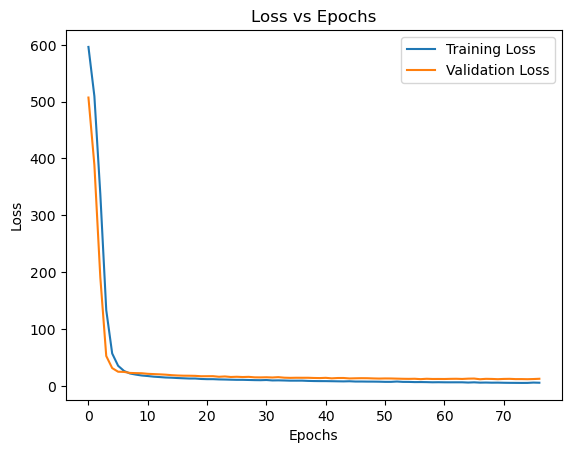

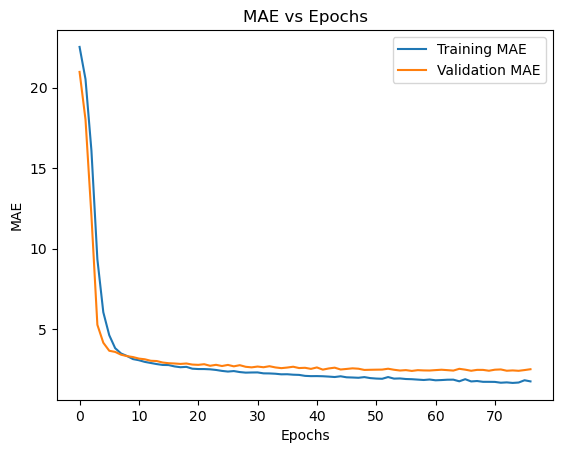

In [19]:
# ==============================
# Step 10: Plot Training Graphs
# ==============================
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.legend()
plt.title("MAE vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.show()